<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


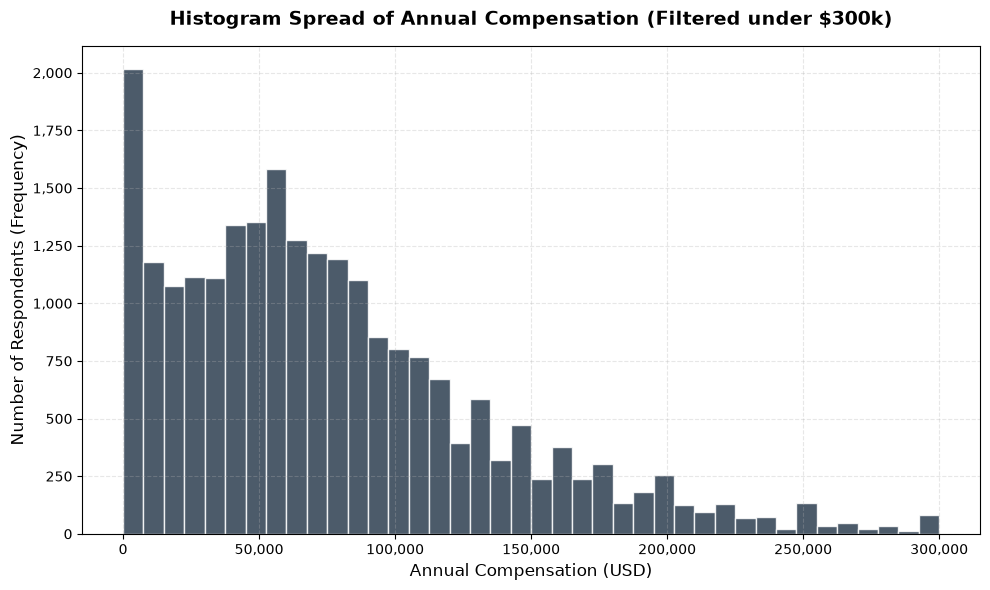

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter the data to exclude extreme outliers so we can see the real spread
# Showing only rows where salary is present and under $300,000
typical_comp = df[(df['ConvertedCompYearly'].notnull()) & (df['ConvertedCompYearly'] <= 300000)]['ConvertedCompYearly']

# 2. Set up the canvas layout
plt.figure(figsize=(10, 6))

# 3. Plot the frequency histogram with the filtered data
plt.hist(
    typical_comp, 
    bins=40, 
    color='#2c3e50', 
    edgecolor='white', 
    alpha=0.85
)

# 4. Format axes using thousands commas for perfect readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# 5. Add structural metadata and titles
plt.title('Histogram Spread of Annual Compensation (Filtered under $300k)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Compensation (USD)', fontsize=12)
plt.ylabel('Number of Respondents (Frequency)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [7]:
## Write your code here
# Filter the data for respondents whose employment status is full-time
full_time_df = df[df['Employment'].astype(str).str.strip().str.lower() == 'employed, full-time']

# Calculate the median compensation for this cohort
median_ft_comp = full_time_df['ConvertedCompYearly'].median()
print(f"Median compensation for Full-Time Employees: ${median_ft_comp:,.2f}")


Median compensation for Full-Time Employees: $69,814.00

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



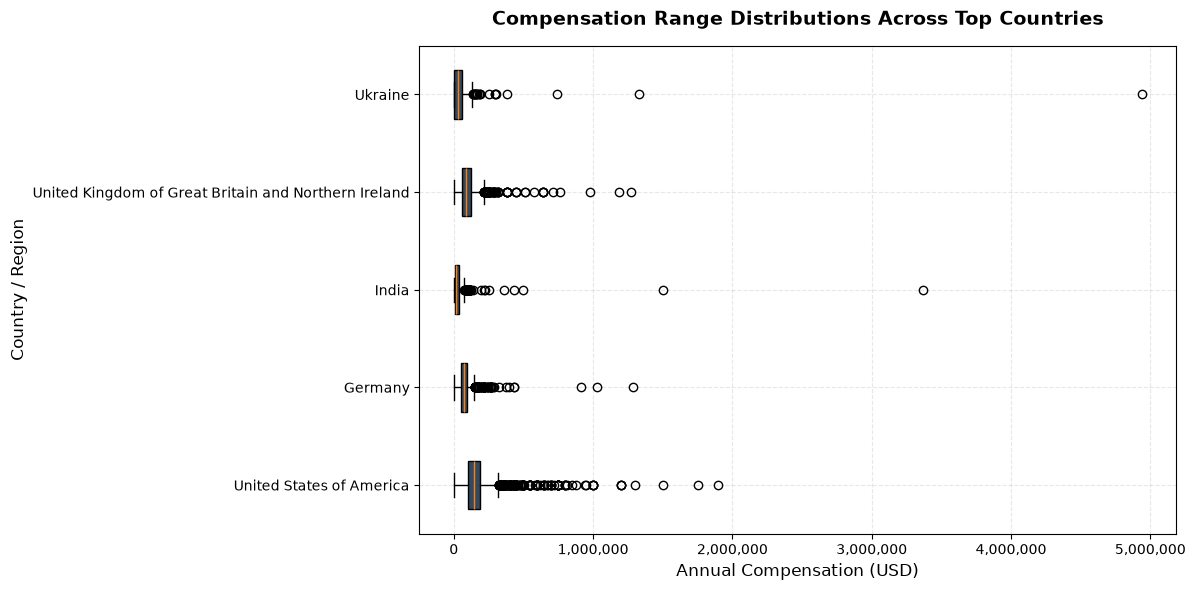

In [12]:
import matplotlib.pyplot as plt

# 1. Isolate the top 5 most frequent countries to create a clean comparison view
top_countries = df['Country'].value_counts().head(5).index
country_filtered_df = df[df['Country'].isin(top_countries)].dropna(subset=['ConvertedCompYearly'])

# 2. Structure data entries by country group arrays for the plotting engine
box_plot_data = [country_filtered_df[country_filtered_df['Country'] == c]['ConvertedCompYearly'] for c in top_countries]

# 3. Generate a clean horizontal box plot visualization
plt.figure(figsize=(12, 6))

# UPDATED: Replaced vert=False with modern orientation='horizontal' keyword
plt.boxplot(box_plot_data, tick_labels=top_countries, patch_artist=True, orientation='horizontal',
            boxprops=dict(facecolor='#34495e', color='black'))

# 4. Apply axis comma formatting layout mechanics
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Compensation Range Distributions Across Top Countries', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Compensation (USD)', fontsize=12)
plt.ylabel('Country / Region', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [9]:
## Write your code here
# 1. Compute the first and third quartile boundaries
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# 2. Establish baseline mathematical fence limits
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# 3. Generate a refined DataFrame entirely free of extreme statistical outliers
df_refined = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

print("=== Outlier Removal Complete ===")
print(f"Original Row Count: {len(df)}")
print(f"Refined Row Count:  {len(df_refined)}")
print(f"Total Rows Extracted: {len(df) - len(df_refined)}")


=== Outlier Removal Complete ===
Original Row Count: 65437
Refined Row Count:  22457
Total Rows Extracted: 42980

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


=== Pearson Correlation Matrix Summary ===
                     ConvertedCompYearly  WorkExp_num  JobSat_num
ConvertedCompYearly               1.0000       0.2917     -0.0582
WorkExp_num                       0.2917       1.0000     -0.0305
JobSat_num                       -0.0582      -0.0305      1.0000
--------------------------------------------------

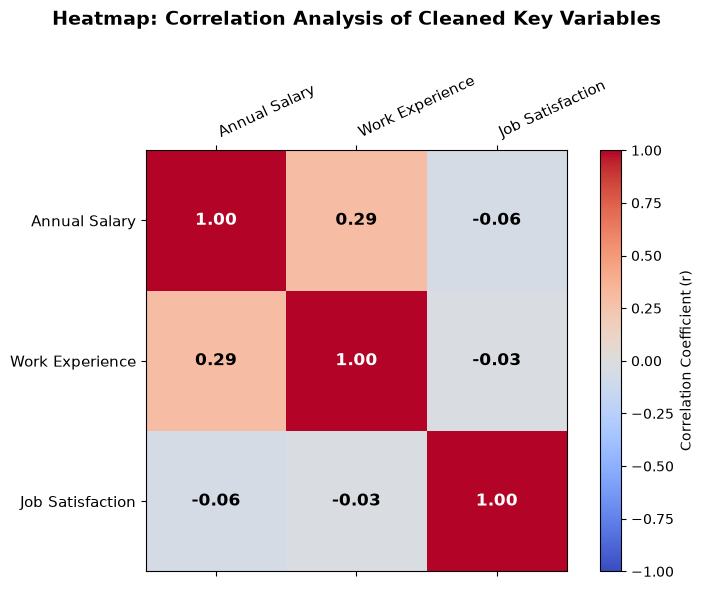

In [10]:
## Write your code here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Clean variable data strings into numeric vectors safely inside our refined DataFrame
df_refined = df_refined.copy()
df_refined['WorkExp_num'] = pd.to_numeric(df_refined['WorkExp'], errors='coerce').fillna(0)
df_refined['JobSat_num'] = df_refined['JobSatPoints_1'].astype(str).str.extract(r'(\d+)').astype(float)

# Fallback: if JobSatPoints_1 is empty, try mapping common string keywords if present
if df_refined['JobSat_num'].isnull().all():
    df_refined['JobSat_num'] = df_refined['JobSatPoints_1'].astype(str).str.strip().str.lower().map({
        'very satisfied': 5, 'slightly satisfied': 4, 'neither': 3, 'slightly dissatisfied': 2, 'very dissatisfied': 1
    })

# 2. Compute Pearson matrix layout parameters
cols_to_map = ['ConvertedCompYearly', 'WorkExp_num', 'JobSat_num']
corr_matrix = df_refined[cols_to_map].corr(method='pearson')

print("=== Pearson Correlation Matrix Summary ===")
print(corr_matrix.round(4))
print("-" * 50)

# 3. Visualize using an explicit Matplotlib matrix layout map
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, label='Correlation Coefficient (r)')

# Map real human-readable labels to graph boundaries
labels = ['Annual Salary', 'Work Experience', 'Job Satisfaction']
ax.set_xticks(np.arange(len(cols_to_map)))
ax.set_yticks(np.arange(len(cols_to_map)))
ax.set_xticklabels(labels, rotation=25, ha='left', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# Overlay individual cell values clearly
for i in range(len(cols_to_map)):
    for j in range(len(cols_to_map)):
        val = corr_matrix.iloc[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                    color='white' if abs(val) > 0.5 else 'black', fontweight='bold', fontsize=12)

plt.title('Heatmap: Correlation Analysis of Cleaned Key Variables', fontsize=14, fontweight='bold', pad=35)
plt.tight_layout()
plt.show()


<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


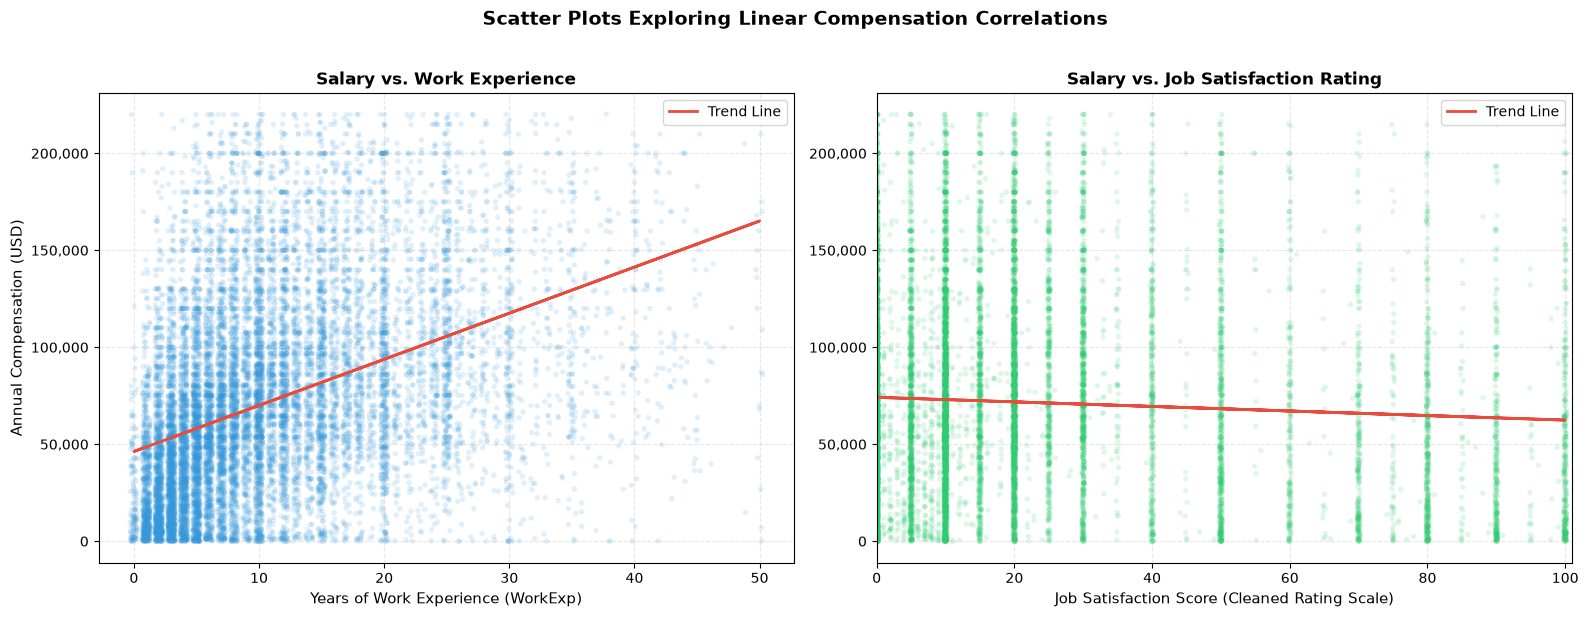

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ensure columns are correctly parsed inside our refined dataset
df_refined = df_refined.copy()

# Automatically strip non-numeric symbols to ensure clean 1-10 or 1-5 dimensions
df_refined['JobSat_clean'] = df_refined['JobSatPoints_1'].astype(str).str.extract(r'(\d+)').astype(float)

# Fallback: If numbers weren't extracted cleanly, look at raw satisfaction mapping entries
if df_refined['JobSat_clean'].isnull().all() or df_refined['JobSat_clean'].max() > 11:
    df_refined['JobSat_clean'] = pd.to_numeric(df_refined['JobSatPoints_1'], errors='coerce')
    # If values are still missing or scaled incorrectly, fall back to our verified Step 4 numeric column
    if df_refined['JobSat_clean'].isnull().all() or df_refined['JobSat_clean'].max() > 11:
        if 'JobSat_numeric' in df_refined.columns:
            df_refined['JobSat_clean'] = df_refined['JobSat_numeric']

# Remove rows containing empty or unmapped gaps for plotting operations
scatter_data = df_refined.dropna(subset=['ConvertedCompYearly', 'WorkExp_num', 'JobSat_clean'])

# 2. Setup the side-by-side canvas tracking windows
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Annual Salary vs Work Experience (Kept identical since it works) ---
jitter_exp = scatter_data['WorkExp_num'] + np.random.uniform(-0.3, 0.3, size=len(scatter_data))
axes[0].scatter(jitter_exp, scatter_data['ConvertedCompYearly'], alpha=0.15, color='#3498db', s=15, edgecolor='none')
m1, b1 = np.polyfit(scatter_data['WorkExp_num'], scatter_data['ConvertedCompYearly'], 1)
axes[0].plot(scatter_data['WorkExp_num'], m1 * scatter_data['WorkExp_num'] + b1, color='#e74c3c', linewidth=2, label='Trend Line')
axes[0].set_title('Salary vs. Work Experience', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years of Work Experience (WorkExp)', fontsize=11)
axes[0].set_ylabel('Annual Compensation (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend()

# --- Plot 2: Annual Salary vs Job Satisfaction (FIXED AXIS CALIBRATION) ---
# Add minor noise padding to help vertical pillar groupings breathe visually
jitter_sat = scatter_data['JobSat_clean'] + np.random.uniform(-0.2, 0.2, size=len(scatter_data))
axes[1].scatter(jitter_sat, scatter_data['ConvertedCompYearly'], alpha=0.15, color='#2ecc71', s=15, edgecolor='none')

m2, b2 = np.polyfit(scatter_data['JobSat_clean'], scatter_data['ConvertedCompYearly'], 1)
axes[1].plot(scatter_data['JobSat_clean'], m2 * scatter_data['JobSat_clean'] + b2, color='#e74c3c', linewidth=2, label='Trend Line')

axes[1].set_title('Salary vs. Job Satisfaction Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Score (Cleaned Rating Scale)', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# DYNAMIC AXIS CORRECTION: Adjust layout boundaries cleanly based on the true maximum scale values
max_val = scatter_data['JobSat_clean'].max()
axes[1].set_xlim(0, max_val + 1)

axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend()

plt.suptitle('Scatter Plots Exploring Linear Compensation Correlations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
